Epoch 1/50


c:\Users\chave\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3104 - loss: 1.1342 - val_accuracy: 0.3736 - val_loss: 0.8017
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4046 - loss: 0.7971 - val_accuracy: 0.5165 - val_loss: 0.6221
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6103 - loss: 0.6418 - val_accuracy: 0.7253 - val_loss: 0.4941
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7881 - loss: 0.5089 - val_accuracy: 0.8132 - val_loss: 0.4019
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8916 - loss: 0.4298 - val_accuracy: 0.8791 - val_loss: 0.3342
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9383 - loss: 0.3189 - val_accuracy: 0.9670 - val_loss: 0.2840
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9540 - loss: 0.2670 - val_accuracy: 0.9670 - val_loss: 0.2468
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9612 - loss: 0.2343 - val_accuracy: 0.9890 - val_loss: 0.2189
Ep

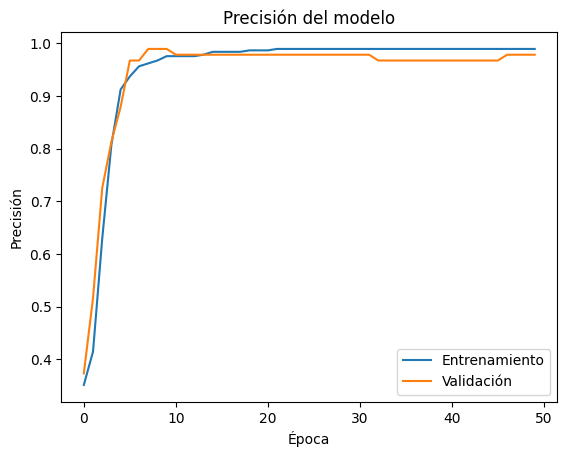

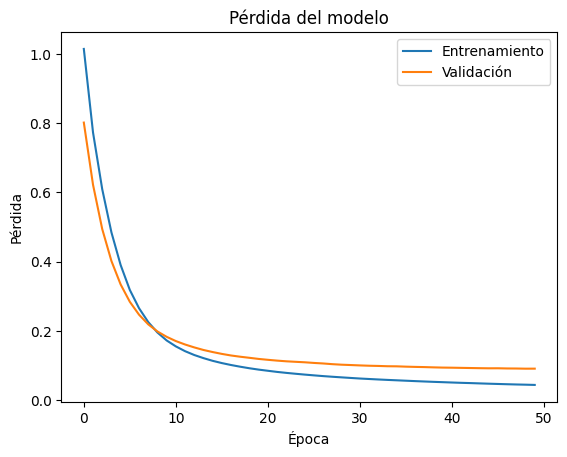

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('E:/Bootcamp/cancer/data.csv')

# Limpiar el dataset
df_clean = df.drop(columns=['id', 'Unnamed: 32'])
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

# Separar características y objetivo
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear el modelo MLP
model = Sequential()
model.add(Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Precisión en el conjunto de prueba: {accuracy*100:.2f}%')

# Graficar el rendimiento durante el entrenamiento
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()


In [2]:
from sklearn.metrics import classification_report, confusion_matrix

# Hacer predicciones en el conjunto de prueba
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Informe de clasificación con precisión, recall y F1-score
report = classification_report(y_test, y_pred, target_names=['Benigno', 'Maligno'])
print("\nInforme de clasificación:")
print(report)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Matriz de confusión:
[[70  1]
 [ 1 42]]

Informe de clasificación:
              precision    recall  f1-score   support

     Benigno       0.99      0.99      0.99        71
     Maligno       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

